In [1]:
import pandas as pd
df =pd.read_csv("Electric_vehicle.csv")
df.head()

,vehicle_id,vehicle_type,battery_capacity_kwh,vehicle_model,vehicle_age,motor_power_kw,vehicle_weight_kg,state_of_charge,battery_temperature,battery_voltage,...,road_condition,traffic_level,terrain,wind_speed,ac_usage,passenger_load,headlight_usage,infotainment_usage,energy_consumption_kwh_per_100km,estimated_range_km
0,EV100000,Scooty,5.03,Ather 450X,7.88,3.67,97.8,48.05,39.05,68.33,...,Poor,High,Hilly,17.86,High,1,On,On,8.00,26.43
1,EV100001,Car,28.51,Hyundai Ioniq 5,11.99,42.02,1669.2,41.78,40.57,402.35,...,Good,Medium,Flat,9.78,Medium,4,On,Off,23.43,40.92
2,EV100002,Bus,154.78,Ashok Leyland Switch,5.62,150.21,8231.3,21.43,22.42,696.31,...,Excellent,Medium,Flat,7.70,Low,13,Off,On,132.98,22.61
3,EV100003,Scooty,6.44,Bajaj Chetak,7.01,10.02,111.5,24.78,12.94,46.13,...,Good,High,Flat,13.60,Low,1,Off,On,8.00,17.61
4,EV100004,Car,59.79,BYD Atto 3,5.16,101.76,1897.4,50.13,30.43,394.63,...,Average,Low,Flat,8.34,Off,2,Off,Off,20.12,133.63


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
df.to_csv("preprocessed_data.csv")
print("Saved")

Saved


In [4]:
df.columns

Index(['vehicle_id', 'vehicle_type', 'battery_capacity_kwh', 'vehicle_model',
       'vehicle_age', 'motor_power_kw', 'vehicle_weight_kg', 'state_of_charge',
       'battery_temperature', 'battery_voltage', 'battery_current',
       'battery_cycles', 'battery_health', 'charging_type', 'charging_time',
       'average_speed', 'maximum_speed', 'acceleration', 'driving_style',
       'distance_travelled', 'regenerative_braking', 'outside_temperature',
       'humidity', 'road_condition', 'traffic_level', 'terrain', 'wind_speed',
       'ac_usage', 'passenger_load', 'headlight_usage', 'infotainment_usage',
       'energy_consumption_kwh_per_100km', 'estimated_range_km'],
      dtype='str')

In [5]:
df.dtypes

vehicle_id                              str
vehicle_type                            str
battery_capacity_kwh                float64
vehicle_model                           str
vehicle_age                         float64
motor_power_kw                      float64
vehicle_weight_kg                   float64
state_of_charge                     float64
battery_temperature                 float64
battery_voltage                     float64
battery_current                     float64
battery_cycles                        int64
battery_health                      float64
charging_type                           str
charging_time                       float64
average_speed                       float64
maximum_speed                       float64
acceleration                        float64
driving_style                           str
distance_travelled                  float64
regenerative_braking                float64
outside_temperature                 float64
humidity                        

In [6]:
x = df.drop("energy_consumption_kwh_per_100km",axis=1)
y = df["energy_consumption_kwh_per_100km"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Testing Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (24000, 30054)
Testing Features:  (6000, 30054)
Training Target:  (24000,)
Testing Target:  (6000,)
Training data
       battery_capacity_kwh  vehicle_age  motor_power_kw  vehicle_weight_kg  \
21753                 68.26        11.96          100.26             2217.5   
251                  174.50        12.56          328.31            12644.3   
22941                 76.57         2.62          113.49             1573.1   
618                   69.05         2.64          136.45             1792.6   
17090                 43.04         8.70           48.67             1985.2   

       state_of_charge  battery_temperature  battery_voltage  battery_current  \
21753            42.60                23.36           339.85           103.40   
251              52.51                31.52           642.67           221.61   
22941            58.39                32.95           378.61            46.37   
618              49.10                15.34           365.50       

In [7]:
import numpy as np

X = df["energy_consumption_kwh_per_100km"]
Y = df["estimated_range_km"]

# Calculate slope
m = (
    ((X - X.mean()) * (Y - Y.mean())).sum()
    / ((X - X.mean()) ** 2).sum()
)

# Calculate intercept
c = Y.mean() - m * X.mean()

# Prediction
Y_pred = m * X + c

print("\nPredicted Range:")
print(Y_pred.head(10))

print("\nSlope:", m)
print("Intercept:", c)


Predicted Range:
0    88.359198
1    89.374120
2    96.579875
3    88.359198
4    89.156402
5    95.777408
6    88.359198
7    88.359198
8    89.332682
9    89.462260
Name: energy_consumption_kwh_per_100km, dtype: float64

Slope: 0.06577594146966381
Intercept: 87.8329900401462


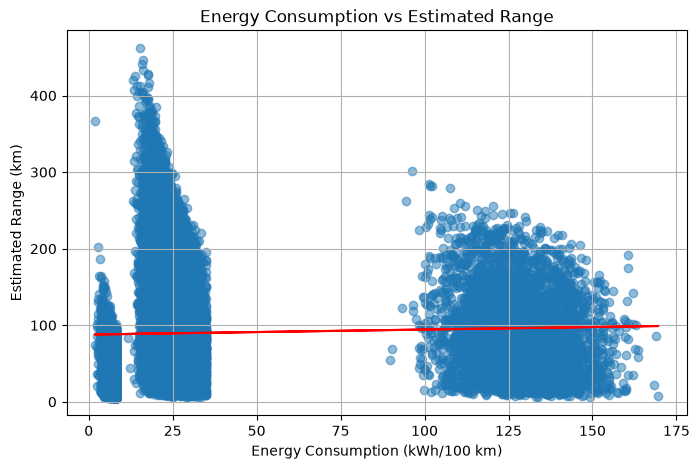

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    Y,
    alpha=0.5
)
plt.plot(
    X,
    Y_pred,
    color="red"
)
plt.title("Energy Consumption vs Estimated Range")
plt.xlabel("Energy Consumption (kWh/100 km)")
plt.ylabel("Estimated Range (km)")

plt.grid(True)
plt.show()

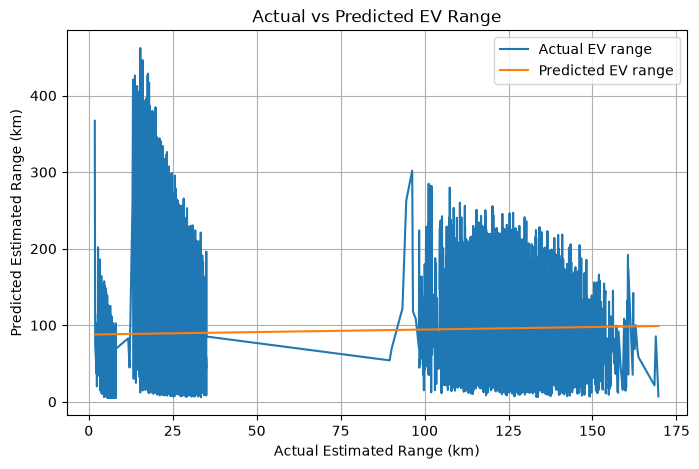

In [12]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual":Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8, 5))

plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual EV range")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted EV range")

plt.title("Actual vs Predicted EV Range")
plt.xlabel("Actual Estimated Range (km)")
plt.ylabel("Predicted Estimated Range (km)")
plt.legend()
plt.grid(True)
plt.show()

Intercept (b0): 87.16801149548132
Slope (b1): 0.0737193938780154

Regression Equation:
Estimated Range = 87.1680 + (0.0737 × Energy Consumption)

Actual vs Predicted Range:
   Energy Consumption  Actual Range  Predicted Range
0               20.11         20.11            88.65
1               22.62         22.62            88.84
2                8.00          8.00            87.76
3               20.32         20.32            88.67
4               21.55         21.55            88.76
5               22.43         22.43            88.82
6              127.96        127.96            96.60
7                7.69          7.69            87.73
8               21.62         21.62            88.76
9               28.85         28.85            89.29


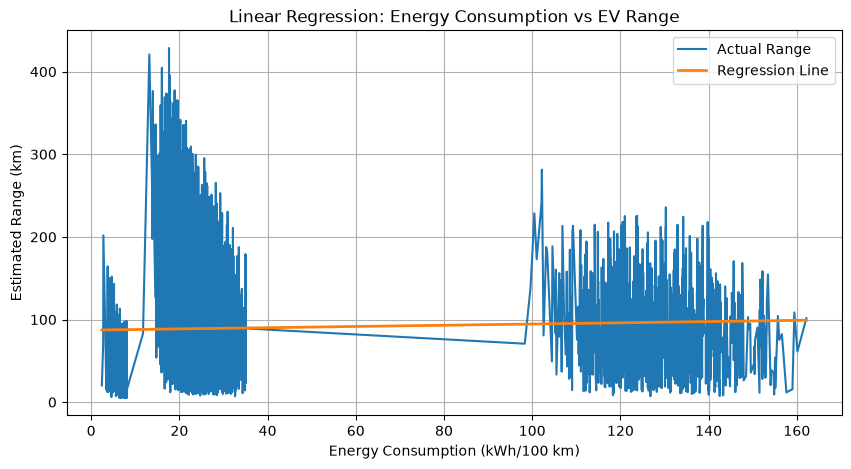

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[["energy_consumption_kwh_per_100km"]]
Y = df["estimated_range_km"]


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, Y_train)

print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

print("\nRegression Equation:")
print(
    f"Estimated Range = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Energy Consumption)"
)

Y_pred = model.predict(X_test)
Y_pred = np.round(Y_pred, 2)
result = pd.DataFrame({
    "Energy Consumption": X_test[
        "energy_consumption_kwh_per_100km"
    ].values,
    "Actual Range": y_test.values,
    "Predicted Range": Y_pred
})

print("\nActual vs Predicted Range:")
print(result.head(10))


plot_data = pd.DataFrame({
    "Energy Consumption": X_test[
        "energy_consumption_kwh_per_100km"
    ].values,
    "Actual Range": Y_test.values,
    "Predicted Range": Y_pred
}).sort_values("Energy Consumption")


plt.figure(figsize=(10, 5))

plt.plot(
    plot_data["Energy Consumption"],
    plot_data["Actual Range"],
    label="Actual Range"
)

plt.plot(
    plot_data["Energy Consumption"],
    plot_data["Predicted Range"],
    linewidth=2,
    label="Regression Line"
)

plt.title("Linear Regression: Energy Consumption vs EV Range")
plt.xlabel("Energy Consumption (kWh/100 km)")
plt.ylabel("Estimated Range (km)")

plt.legend()
plt.grid(True)

plt.show()